# Zeitlin model with constraints

This notebook is a demonstration of how to use `quflow` with constraints.

First some theory. Suppose we have some domain $ D \subset S^2$ defined by $D = f^{-1}((-\infty , c))$ for some $c \in \mathbb R$, and $\partial D = f^{-1}(c)$. We want to solve the partial differential equaiton $\Delta \psi = \omega$ on $D$ with the boundary condition $\psi$ is constant on $\partial D$. This is equivalent to $\nabla \psi \wedge \mathbf n = 0$, where $n$ is the unit normal on $\partial D$. Since we know that $f \equiv c$ on $\partial D$, we know that $ \nabla f/|\nabla f| = \mathbf n$(We assume that $\nabla f$ does not vanish). Using the correspondance between vector fields and 1-forms, we can therefore instead use the boundary condition
$$
   \star ( d\psi \wedge df) = 0  \quad \text{on $\partial D$.}
$$
We can do approximately* the same by letting
$$
    f_c(x) = \begin{cases} f(x) & x \text{ is close to } c \\
    0 & \text{else}
    \end{cases}
$$
and require that 
$$
    \star (d\psi \wedge df_c)  = \{ \psi , f_c\} = 0 
$$
(* If we do a cutoff of $f$, $df_c$ can approach "dirac delta"/"infinite" in the normal direction, but this is fine as we only care about direction)

Going to the matrix case we have $P$ instead of $\psi$ and $F$ instead of $f$. Assume for simplicity that $c$ is an eigenvalue of $F$, with corresponding eigenvector $e_c$. Then $F_c = c\mathbf e_c \mathbf e_c^\ast$ corresponds to $f_c$. We therefore have the boundary condition $[P, F_c] =0$

Now back to the continuous formulation. It is well-known that solving $-\Delta \psi = -\omega$ on $S^2$ is equivalent to 

$$
\mathrm{minimize} \quad \frac 1 2 \langle -\Delta \psi , \psi  \rangle  + \langle \omega , \psi \rangle 
$$
Adding the boundary condition with a lagrange multiplier, we are looking for a stationary point of

$$ 
    S(\psi, \lambda) = \frac 1 2  \langle  - \Delta \psi, \psi \rangle + \langle \omega, \psi \rangle + \int_{\partial D} \{ \psi ,f\}\lambda
$$
that is 
$$
     0 =  \delta S( \psi , \lambda ; q , \mu) = \langle -\Delta \psi , q \rangle + \langle \omega, q \rangle + \int_{\partial D} 
     \{\psi , f\}\mu + \int_{\partial D} 
     \{q, f\}\lambda
$$
for all $q$ and $\mu$. For $\mu =0$ we have that
$$
 \langle -\Delta \psi , q \rangle + \langle \omega, q \rangle =0
$$
for all $q \in C_0^\infty(D)$, which means that at a stationary point $\Delta \psi = \omega$ on $D$.

Using the approximation $f_c$ we have
$$
    \int_{\partial D} \{q, f\}\lambda \approx \int_{S^2} \{q, f_c\} \lambda =  \int_{S^2} \{ \lambda, f_c\}q
$$

Back to the matrix formulation we arrive at the saddle point problem

$$
    -\Delta_N P + [\lambda, F_c] =-W \\
    [P, F_c] + 0  =0 
$$

In [1]:
# For non-interactive plots:
%matplotlib inline

# Looks better on macbooks
%config InlineBackend.figure_format = 'retina' 

# Modules to load
import numpy as np
import matplotlib.pyplot as plt
import quflow as qf
from quflow.constraints import *

# Matplotlib style
# plt.style.use('dark_background')
# plt.style.use('default')

### Parameters

In [2]:
N = 512

filename = "mysim_N_{}.hdf5".format(N)
prerun_code = ""

### Define the constraint function F

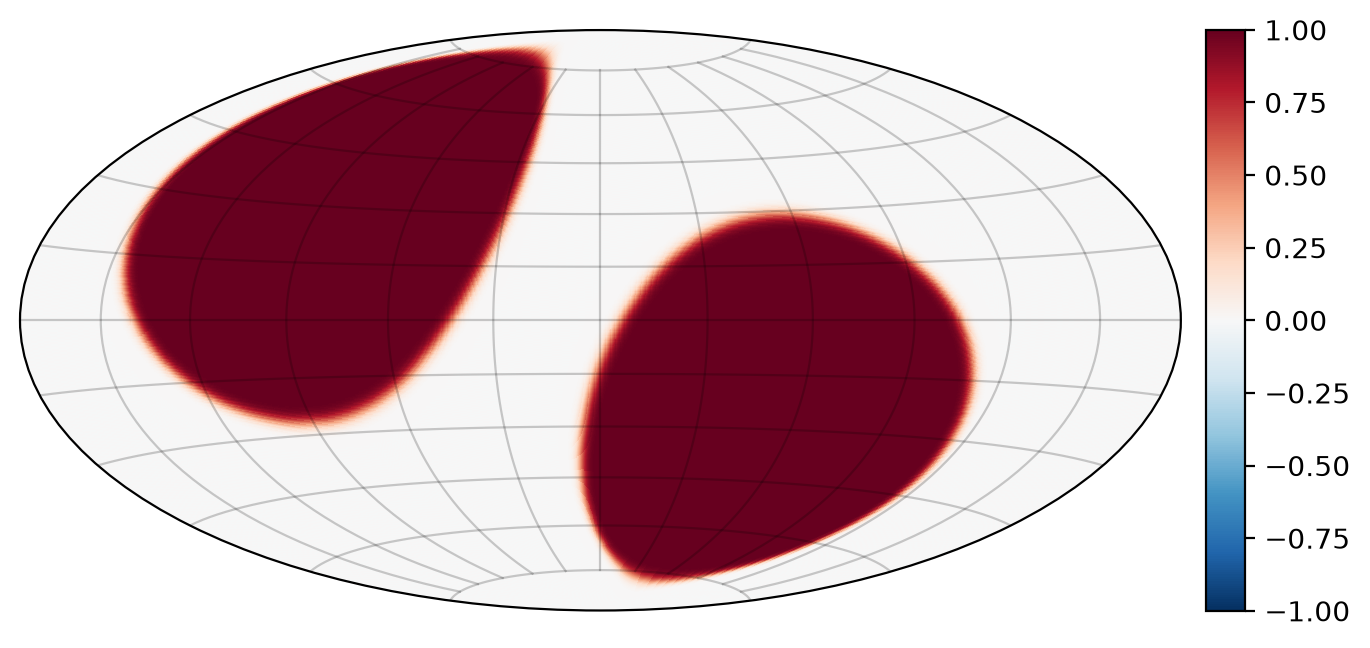

In [3]:
f1 = island_mask(N, center=[0.0,2.0,-1.0], radius=0.9)
f2 = island_mask(N, center=[-0.7,-1.0,0.55], radius=0.9)


f = scipy.ndimage.gaussian_filter(np.logical_or(f1, f2).astype(np.float64), 5.0)
F = qf.shr2mat(qf.fun2shr(f))
qf.plot(F,colorbar=True)
#plot_eigenvalues(F,greater_than=0.5,less_than=0.8)


### Restrict eigenvalues of F to F_c

In [14]:
# Coastline parameters
level_set_center = 0.5  # target eigenvalue (imaginary part)
level_set_epsilon =0.03 # half-width: smaller = fewer coastline eigenvalues = sparser constraints

F_c, K = level_set_eigenvects(F, level_set_center ,[-np.inf, 0], linear=false)
def plotF(W):
    return qf.plot(W, contour_data=F, contours=[level_set_center -0.02,level_set_center,level_set_center +0.02],colorbar=True)
print(f"Retained K = {K} coastline eigenvalues out of N = {N}")

print("Commutator rank", commutator_rank(F_c))
print("Rank of C", K*(2*N - K -1))
plotF(F)
plotF(F_c)


NameError: name 'false' is not defined

## Generate random vorticity and plot it

gamma ratio is 0.0


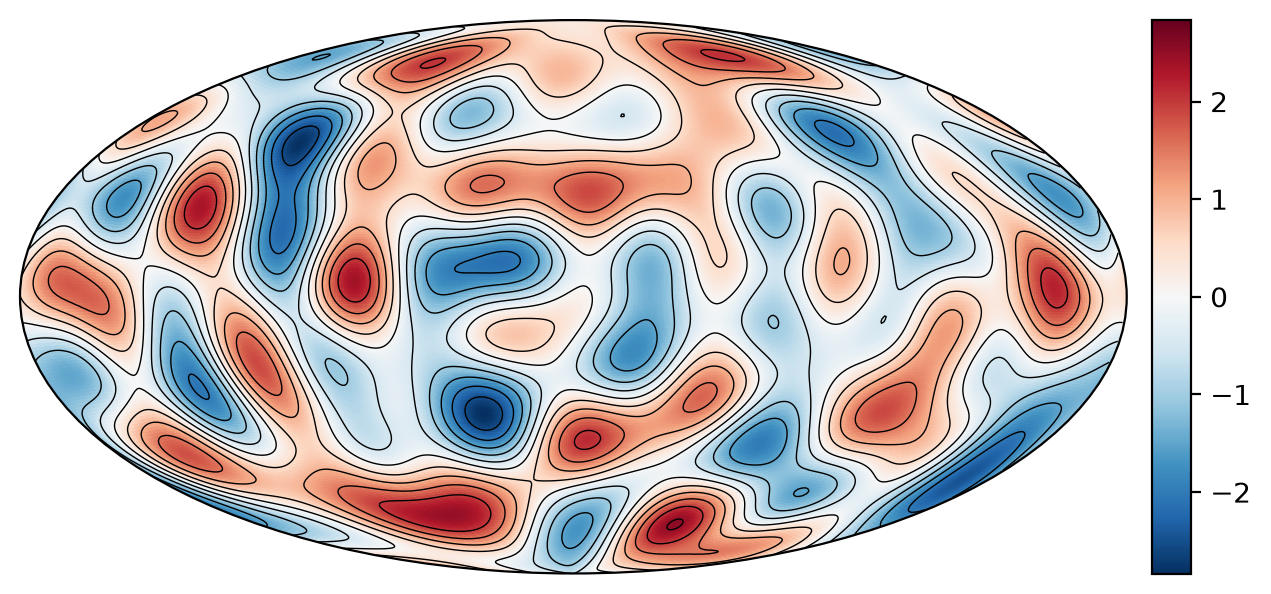

In [12]:
import matplotlib.colors as colors

omega0 = qf.analysis.random_shr(lmax=10, s=0.0, gamma=0., seed=42)
els, ms = qf.ind2elm(np.arange(omega0.shape[0]))
im = qf.plot(omega0, N=256, colorbar=True, grid=False, contours=10)
print("gamma ratio is {}".format(qf.analysis.gamma_ratio(omega0)))
# plt.savefig('initial_vorticity.png', transparent=True, dpi=300)
plt.show()
W0 = qf.shr2mat(omega0, N=N)  # Convert SH coefficients to matrix

## Make the initial vorticity be zero on the islands


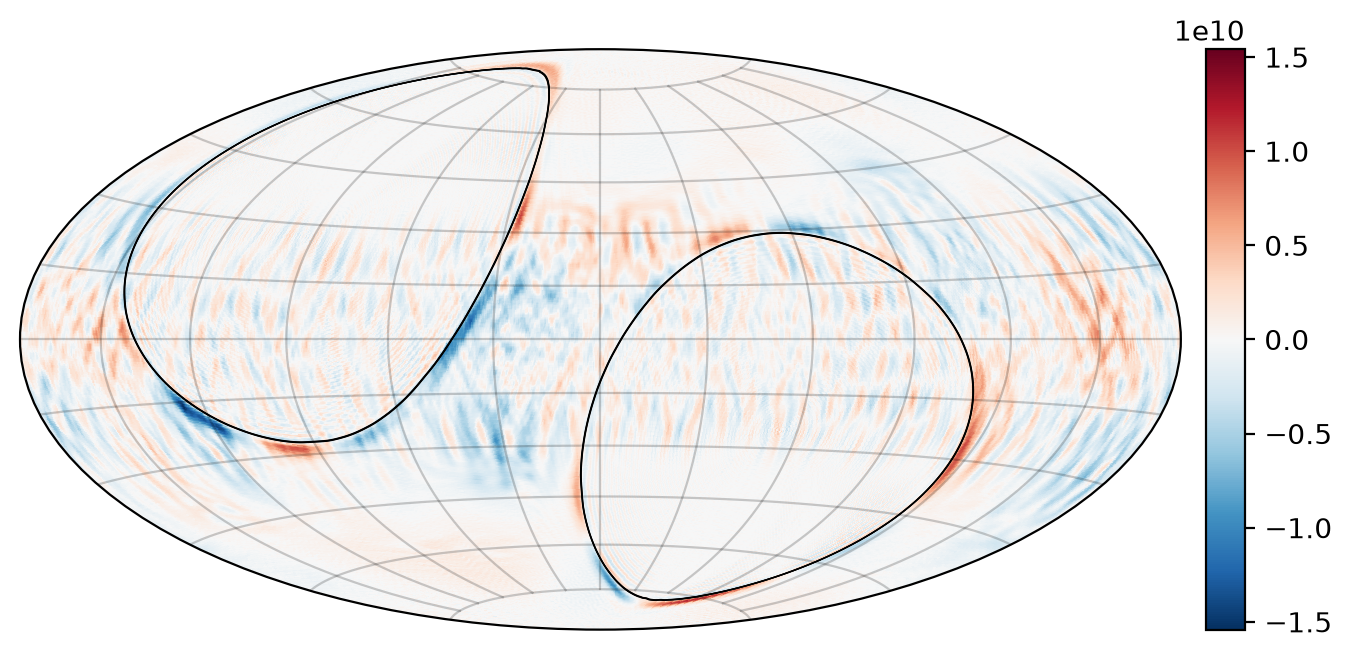

In [13]:
def project(W):
    return F_c@(F_c.conj().T@W@F_c)@F_c.conj().T

W0_proj = project(W0)
plotF(W0_proj)


## Simulation of Euler's equations on the sphere

In vorticity formulation, Euler's equations are
$$\dot\omega = \{\psi,\omega\} $$
where $\omega$ is the vorticity function and $\psi$ is the stream function (related to $\omega$ via Poisson's equation). The quantized Euler equations are similar
$$\dot W = \frac{1}{\hbar}[P,W] $$
but here the vorticity function is replaced by the vorticity matrix $W \in \mathfrak{su}(N)$ and a corresponding stream matrix $P\in\mathfrak{su}(N)$.


## Externally defined functions

This steps is *very* important for cluster simulations: any code needed for the simulation that is not already part of `quflow`, must be specified here. This also includes variables that are needed at runtime.

In [ ]:
# For example, define logger functions
# (exactly these loggers are also defined in `qf.physics.energy_euler` and `qf.physics.enstrophy`)
def energy(W):
    P = qf.solve_poisson(W)
    return -qf.geometry.inner_L2(W, P)

def enstrophy(W):
    return qf.geometry.inner_L2(W, W)

# For example, define a new Poisson solver here:
def solve_poisson_special(W):
    raise NotImplementedError()


# It is a good practice to save this code as
# a string and it to the QuSimulation object.
# Then the code can easily be moved to a cluster.
prerun_code += In[len(In)-1]


## Define the solver dependent on F_c
We do the whole construction of F_c again in one cell. The code in the cell will be added to the runfile.

In [ ]:
prerun_code +=f"""
from quflow.constraints import *

N = {N}

f1 = island_mask(N, center=[0.0,2.0,-1.0], radius=0.9)
f2 = island_mask(N, center=[-0.7,-1.0,0.55], radius=0.9)

f = scipy.ndimage.gaussian_filter(np.logical_or(f1, f2).astype(np.float64), 5.0)
F = qf.shr2mat(qf.fun2shr(f))

level_set_center = {level_set_center}  # target eigenvalue (imaginary part)
level_set_epsilon ={level_set_epsilon} # half-width: smaller = fewer coastline eigenvalues = sparser constraints


F_c, K = level_set_eigenvects(F, level_set_center,2)

solver = qf.constraints.BoundaryConditionPoisson(F_c, N,row_selection="interpolative_operator",normalize_rows = True)


"""

## Make the simulation object

In [ ]:
# Simulation
simtime = 100
inner_time = 0.2
dt = 0.25 * qf.hbar(N)
W0 = W0_proj

# Callback data object
mysim = qf.QuSimulation(filename, overwrite=True, state=W0, 
                        loggers={'energy':qf.physics.energy_euler, 'enstrophy':qf.physics.enstrophy})

# Set parameters for `solve` function. This is VERY convenient when moving a 
# simulation from your computer to the cluster.
mysim['dt'] = dt
mysim['simtime'] = simtime
mysim['inner_time'] = inner_time
mysim['prerun'] = prerun_code
mysim['integrator'] = qf.isomp



## Create Python script for running the simulation

Run the cell below to generate a Python script for running the simulation. If you like, you can edit it after.

In [ ]:
qf.create_runfile(mysim, runfilename="mysim_runfile.py")

## Create shell script

This script is specific for Vera, but can easily be modified for other systems based on Slurm. It is important that you specify the right project number under parameter `#SBATCH -A`.

We use the cluster Vera available via [C3SE](https://www.c3se.chalmers.se/). The setup can be adapted to other settings.

In [ ]:
%%writefile run_vera.sh
#!/bin/env bash
#SBATCH -A C3SE2026-1-16 -p vera # find your project with the "projinfo" command
#SBATCH -t 7-00:00:00 # maximum simulation time is 7 days
#SBATCH -J quflow-sim # name of job
#SBATCH -n 1 # number of tasks to run
#SBATCH -c 4 # number of cores per task
#SBATCH -N 1 # use maximum 1 node
#SBATCH -C ZEN4|ICELAKE # Use ZEN4 or ICELAKE or ZEN4|ICELAKE

# Run script for starting simulations on Vera

basedir=$(dirname "$0")
if command -v module &> /dev/null
then
    # if [[ $SLURM_NTASKS =~ ^[0-9]+$ ]]; then
    #     export OMP_NUM_THREADS=$((SLURM_NTASKS*SLURM_CPUS_PER_TASK))
    # fi
    echo "Max number of threads: $OMP_NUM_THREADS"

    echo "Loading modules ..."

    # Current 
    module load FlexiBLAS/3.4.5-GCC-14.3.0
    module load SciPy-bundle/2025.07-gfbf-2025b
    module load FFmpeg/7.1.2-GCCcore-14.3.0
    module load FFTW/3.3.10-GCC-14.3.0
    module load tqdm/4.67.1-GCCcore-14.3.0
    module load matplotlib/3.10.5-gfbf-2025b
    module load virtualenv/20.32.0-GCCcore-14.3.0
    module load numba/0.62.0-foss-2025b
    module load h5py/3.14.0-foss-2025b

    # Load these for CUDA-simulations
    # Improvement: Probably better to check if variable 
    # $SLURM_JOB_GPUS or $SLURM_GPUS_ON_NODE
    # is non-empty and then load them
    #
    # Example values from VERA:
    # (none of these are set if no GPU is specified) 
    # > echo $SLURM_JOB_GPUS
    # 0
    # > echo $SLURM_GPUS_ON_NODE
    # 1
    # > echo $SLURM_GPUS_PER_NODE
    # A100:1
    #
    if [[ -v SLURM_GPUS_ON_NODE ]]; then 
        echo "GPU found"
        module load CuPy/13.6.0-foss-2025b-CUDA-12.9.1
        module load CUDA-Python/12.9.2-gfbf-2025b-CUDA-12.9.1
        module load numba-cuda/0.20.0-foss-2025b-CUDA-12.9.1
    fi

    if [[ `lscpu` == *"AuthenticAMD"* ]]; then 
        echo "AMD hardware found"
        export FLEXIBLAS=AOCL_MT
    else
        echo "Assuming Intel hardware"
        module load imkl/2025.2.0
        export FLEXIBLAS=IMKL
    fi
    echo "...done loading module"

    if [ -d ${HOME}/quflow-addons ]; then 
        echo "Environment ~/quflow-addons exists, activating it ..."
        # Load virtualenv
        source ${HOME}/quflow-addons/bin/activate
        echo "...done"
    else
        # Create virtualenv. You can change "quflow-addons-amd" to some other name
        # if you need to keep several environments.
        echo "Creating virtual environment ~/quflow-addons ..." 
        virtualenv --system-site-packages ${HOME}/quflow-addons
        echo "...done"

        # Load virtualenv
        source ${HOME}/quflow-addons/bin/activate

        # Install quflow as an editable module (located in the home folder)
        if [ -d ${HOME}/quflow ]; then
            echo "Local quflow directory ~/quflow exists"

            # Install quflow to the virtualenv
            echo "Pip-installing editable quflow into ~/quflow-addons ..."
            pip install -e ${HOME}/quflow
            echo "...done"

        else
            # Install non-editable (regular) quflow
            echo "Pip-installing non-editable quflow into ~/quflow-addons ..."
            pip install https://github.com/andrmykl/quflow/archive/boundary-conditions-simplified.zip
            echo "...done"
        fi
    fi
fi

echo "Running command: python -u $@"
start=`date +%s`
python -u "$@"
end=`date +%s`
runtime=$((end-start))
echo "...finished in $runtime seconds"

Overwriting run_vera.sh


## Make a shell script for submitting the simulation
This script will automatically copy the files and run the simulation on the cluster. It works like

./submit_vera.sh -n N -t SIMTIME -c CORES

Paste your vera username in the cell below

In [ ]:
%%writefile submit_vera.sh
#!/usr/bin/env bash

set -euo pipefail

usage() {
    echo "Usage: $0 -n N -t SIMTIME -c CORES"
    exit 1
}

N=""
SIMTIME=""
CORES=""

while getopts ":n:t:c:" opt; do
    case "$opt" in
        n) N="$OPTARG" ;;
        t) SIMTIME="$OPTARG" ;;
        c) CORES="$OPTARG" ;;
        *) usage ;;
    esac
done

if [[ -z "$N" || -z "$SIMTIME" || -z "$CORES" ]]; then
    usage
fi

HDF5_FILE="mysim_N_${N}.hdf5"
PY_FILE="mysim_runfile.py"
SBATCH_FILE="run_vera.sh"

for f in "$HDF5_FILE" "$PY_FILE" "$SBATCH_FILE"; do
    [[ -f "$f" ]] || { echo "Missing file: $f" >&2; exit 1; }
done

scp "$HDF5_FILE" "$PY_FILE" "$SBATCH_FILE" vera1:~/

ssh vera1 "
    cd ~ &&
    sbatch -c ${CORES} ${SBATCH_FILE} ${PY_FILE} --simtime ${SIMTIME} -f ${HDF5_FILE}
"

sleep 5

ssh vera1 "squeue -u andmyk"

Overwriting submit_vera.sh


## Copy video file back

In [ ]:
%%writefile move_video_back_vera.sh
#!/usr/bin/env bash

set -euo pipefail

usage() {
    echo "Usage: $0 -n N"
    exit 1
}

N=""

while getopts ":n:" opt; do
    case "$opt" in
        n) N="$OPTARG" ;;
        *) usage ;;
    esac
done

if [[ -z "$N" ]]; then
    usage
fi

REMOTE_FILE="mysim_N_${N}.mp4"
REMOTE_HOST="vera1"
REMOTE_USER="andmyk"

# Optional: local destination (current directory)
LOCAL_DIR="."

echo "Copying ${REMOTE_FILE} from ${REMOTE_HOST}..."

scp "${REMOTE_HOST}:~/${REMOTE_FILE}" "${LOCAL_DIR}/"

echo "Done: ${LOCAL_DIR}/${REMOTE_FILE}"

Overwriting move_video_back_vera.sh


## Run a short simulation

This is just to try things out (so that the stepsize is reasonable). A good aim is to have about 4 iterations per time-step.

In [ ]:
import time
start = time.time()
solver1 = qf.constraints.BoundaryConditionPoisson(F_c, N,row_selection="interpolative",verbose= True, normalize_rows=False )
end = time.time()
print(f"Time taken: {end - start} seconds")
start = time.time()
solver2 = qf.constraints.BoundaryConditionPoisson(F_c, N,row_selection="interpolative",verbose= True)
end = time.time()
print(f"Time taken: {end - start} seconds")
start = time.time()
solver3 = qf.constraints.BoundaryConditionPoisson(F_c, N,row_selection="interpolative_operator",verbose= True)
end = time.time()
print(f"Time taken: {end - start} seconds")


MemoryError: Unable to allocate 1.00 TiB for an array with shape (262144, 262144) and data type complex128

In [ ]:
start = time.time()
solver4 = qf.constraints.BoundaryConditionPoisson(F_c, N,row_selection="interpolative_operator",verbose= True, normalize_rows = False)
end = time.time()
print(f"Time taken: {end - start} seconds")
start = time.time()
solver4 = qf.constraints.BoundaryConditionPoisson(F_c, N,row_selection="real_interpolative_operator",verbose= True, normalize_rows = True)
end = time.time()
print(f"Time taken: {end - start} seconds")

Selected constraint matrix V: shape=(250, 4096), nnz=31747, density=3.100293e-02, sparsity=9.689971e-01, normalized=True, row_norm_tol=1.0e-12, dropped_tiny_rows=0
Time taken: 1.6249370574951172 seconds
Selected constraint matrix V: shape=(250, 4096), nnz=31743, density=3.099902e-02, sparsity=9.690010e-01, normalized=True, row_norm_tol=1.0e-12, dropped_tiny_rows=0
Time taken: 1.4489846229553223 seconds


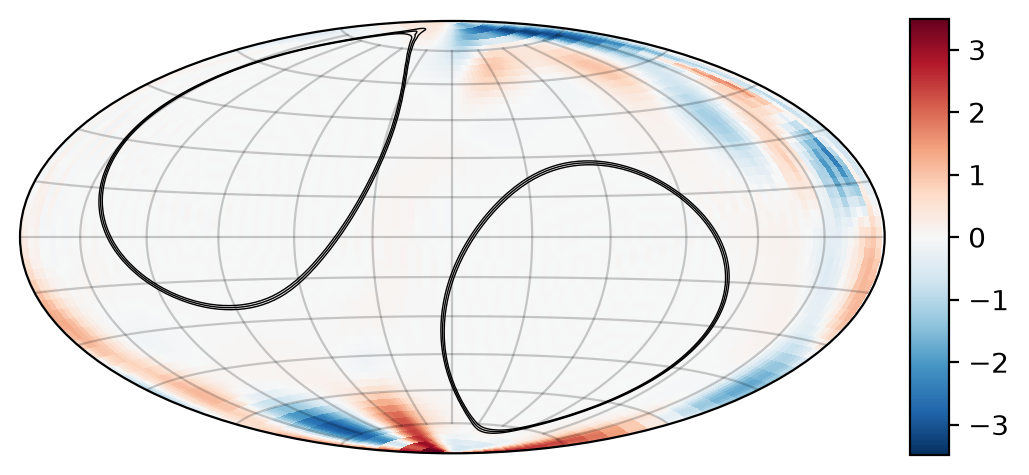

In [ ]:
omega0 = qf.analysis.random_shr(lmax=10, s=0.0, gamma=0)
W0 = qf.shr2mat(omega0, N=N)  # Convert SH coefficients to matrix
W0_proj = project_soft(W0,F,level_set_center,level_set_epsilon+0.05, epsilon=0.005)
np.linalg.trace(W0_proj)
plotF(W0_proj)



In [ ]:
relative_err_constrained1 =0
relative_err_constrained2 =0
relative_err_constrained3 =0
relative_err_constrained4 =0
relative_err_constrained5 =0
omega0 = qf.analysis.random_shr(lmax=10, s=0.0, gamma=0)
W0 = project_soft(qf.shr2mat(omega0, N=N),F,level_set_center,level_set_epsilon+0.05, epsilon=0.005)  # Convert SH coefficients to matrix
P1 = solver1.solve(W0)
P2 = solver2.solve(W0)
P3 = solver3.solve(W0)
P4 = solver4.solve(W0)
P5 = solver5.solve(W0)

relative_err_constrained1 += np.linalg.norm(F_c @ P1 - P1 @ F_c)/(np.linalg.norm(F_c)*np.linalg.norm(P1))
relative_err_constrained2 += np.linalg.norm(F_c @ P2 - P2 @ F_c)/(np.linalg.norm(F_c)*np.linalg.norm(P2))
relative_err_constrained3 += np.linalg.norm(F_c @ P3 - P3 @ F_c)/(np.linalg.norm(F_c)*np.linalg.norm(P3))
relative_err_constrained4 += np.linalg.norm(F_c @ P4 - P4 @ F_c)/(np.linalg.norm(F_c)*np.linalg.norm(P4))
relative_err_constrained5 += np.linalg.norm(F_c @ P5 - P5 @ F_c)/(np.linalg.norm(F_c)*np.linalg.norm(P5))

print(f"Error in constraint: {relative_err_constrained1/100}")
print(f"Error in constraint: {relative_err_constrained2/100}")
print(f"Error in constraint: {relative_err_constrained3/100}")
print(f"Error in constraint: {relative_err_constrained4/100}")
print(f"Error in constraint: {relative_err_constrained5/100}")



Error in constraint: 4.096894731028092e-17
Error in constraint: 3.720215699292681e-17
Error in constraint: 3.7466274217653083e-17
Error in constraint: 2.3954643298558402e-17
Error in constraint: 3.195163119575559e-17


  0%|          | 0/31996 [00:00<?, ? steps/s]

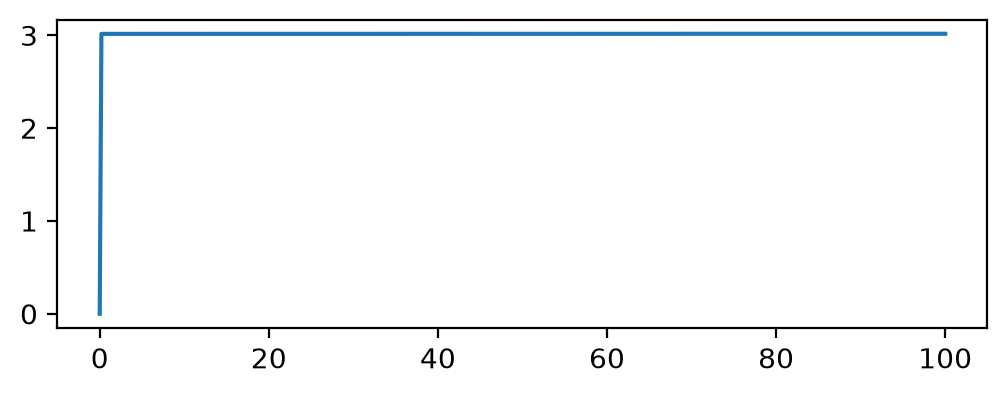

In [ ]:
# Run simulation directly from QuSimulation object
qf.solve(mysim,hamiltonian=solver3.solve)

# Plot average number of iterations over time.
# This is a good check that everything went well 
# (you should select the time-step so that you 
# never hit `maxit` which defaults to 10).
with plt.rc_context({'figure.figsize':(6,2)}), qf.QuSimulation(filename) as mysim:
    plt.plot(mysim['time'], mysim['iterations'])

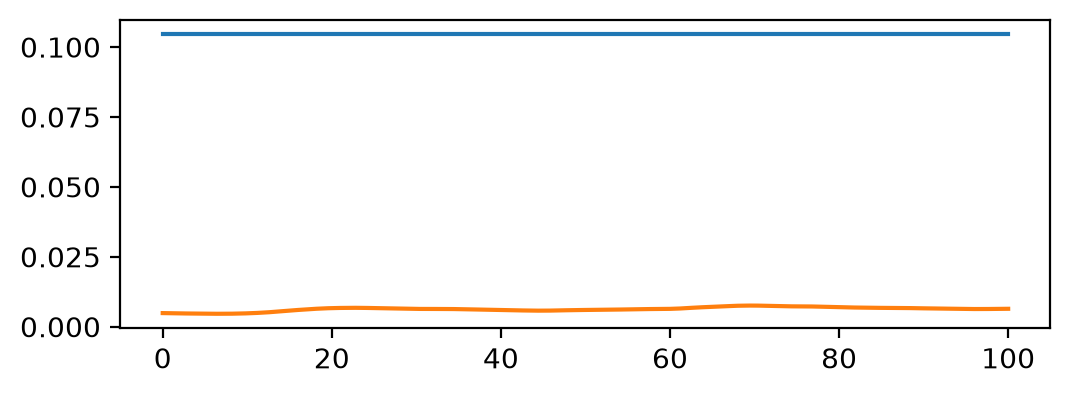

In [ ]:
# Plot energy and enstrophy
with plt.rc_context({'figure.figsize':(6,2)}), qf.QuSimulation(filename) as mysim:
    plt.plot(mysim['time'], mysim['enstrophy'])
    plt.plot(mysim['time'], mysim['energy'])

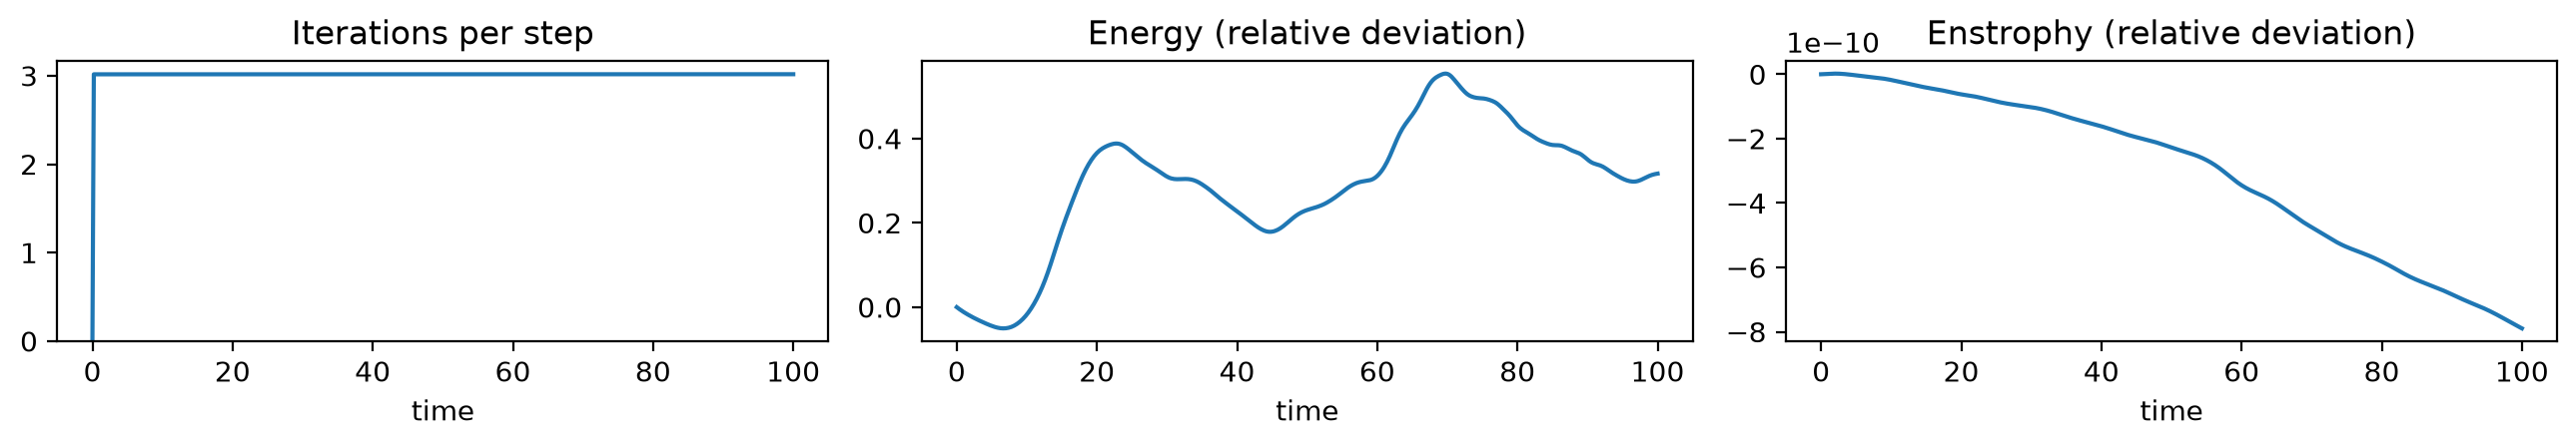

In [ ]:
with qf.QuSimulation(filename) as sim:
    time = sim['time']
    energy = sim['energy']
    enstrophy = sim['enstrophy']
    iterations = sim['iterations']

fig, axes = plt.subplots(1, 3, figsize=(13, 2.5))

axes[0].plot(time, iterations)
axes[0].set_title('Iterations per step')
axes[0].set_xlabel('time')
axes[0].set_ylim(bottom=0)

E0 = energy[0]
axes[1].plot(time, (energy - E0) / abs(E0))
axes[1].set_title('Energy (relative deviation)')
axes[1].set_xlabel('time')
axes[1].ticklabel_format(axis='y', style='scientific', scilimits=(-2, 2))

S0 = enstrophy[0]
axes[2].plot(time, (enstrophy - S0) / abs(S0))
axes[2].set_title('Enstrophy (relative deviation)')
axes[2].set_xlabel('time')
axes[2].ticklabel_format(axis='y', style='scientific', scilimits=(-2, 2))

plt.tight_layout()


In [ ]:
from tqdm import tqdm
from IPython.display import Video

animfile = filename.replace(".hdf5", ".mp4")

with qf.QuSimulation(filename) as mysim, qf.Animation(
    animfile,
    N=256,
    contour_data=F,
    contours=[level_set_center],
    grid=False,
    colorbar=True
) as anim:
        for k in tqdm(range(0, len(mysim['time']))):
            t = mysim['time', k]
            data = mysim['fun', k]
            anim.update(data, time=t)

        


100%|██████████| 501/501 [00:34<00:00, 14.36it/s]


## Copy files to the cluster

Now copy the `quflow` simulation file `mysim_N_512.hdf5`, the Python script file `mysim_runfile.py`, and the cluster-specific shell command file `run_vera.sh` to Vera, for example via `scp`. More information on how to copy files to Vera can be found at [this link](https://www.c3se.chalmers.se/documentation/file_transfer/).

## Start the simulation on Vera

Now login via `ssh` to Vera. Change to the directory where you uploaded your files. Now, to schedule a `quflow` run on Vera, execute the following command:
```
sbatch -c 8 run_vera.sh mysim_runfile.py --simtime 100 -f mysim_N_512.hdf5
```
Here, the option `--simtime` specifies the simulation time for the run (added to the last output time). One can also use the option `--endtime` which sets the absolute end simulation time. The option `-c` specifies the number of cores to use. A good rule for the number of cores is as follows

| N | cores |
|---|-------|
|256 | 4 |
|512 | 8 |
|1024 | 16 |
|2048 | 32 |